# a3 - The retention viz gallery
learn-customer-retention-with-phoebe - by Phoebe Fu

Five charts every retention analyst should be able to produce from the same cohort objects built
in a2: overlaid cohort curves, the truncated-cohort trap, the layer-cake, growth accounting with
quick ratio, and the L28 power-user histogram.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
retail = orders[orders["segment"] == "retail"].copy()

# Rebuild the a2 objects (the canonical recipe)
retail["order_month"] = retail["order_date"].dt.to_period("M")
retail["cohort"] = retail.groupby("customer_id")["order_date"].transform("min").dt.to_period("M")
retail["period_number"] = (retail["order_month"] - retail["cohort"]).apply(lambda p: p.n)
counts = retail.pivot_table(index="cohort", columns="period_number",
                            values="customer_id", aggfunc="nunique")
retention = counts.divide(counts.iloc[:, 0], axis=0)
retention.shape

(12, 14)

## 1. Overlaid cohort curves

Every row of the triangle is a curve. Fade the old cohorts to grey and highlight the newest three
in the course orange so the eye answers the only question that matters: are new cohorts retaining
better or worse than old ones?

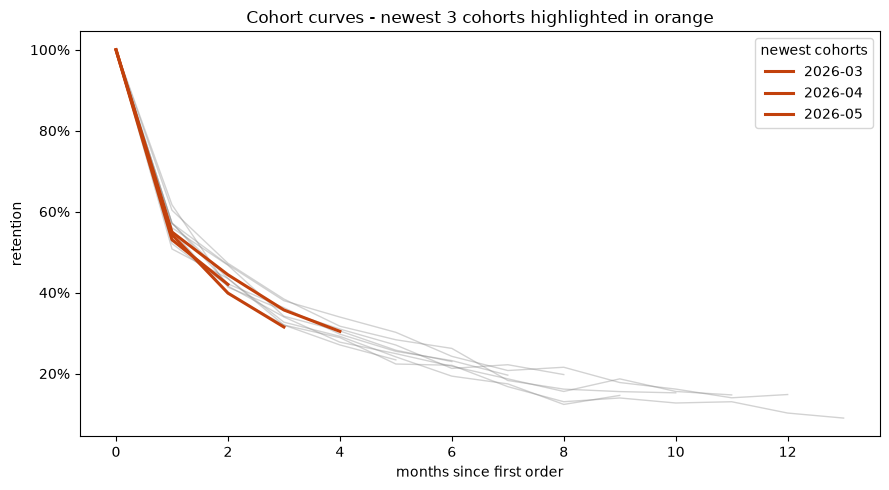

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
cohorts = list(retention.index)
newest = cohorts[-3:]
for c in cohorts:
    row = retention.loc[c].dropna()
    if c in newest:
        ax.plot(row.index, row.values, color="#C2410C", linewidth=2.2, label=str(c))
    else:
        ax.plot(row.index, row.values, color="grey", alpha=0.35, linewidth=1)
ax.set_xlabel("months since first order")
ax.set_ylabel("retention")
ax.set_title("Cohort curves - newest 3 cohorts highlighted in orange")
ax.legend(title="newest cohorts")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout()
plt.show()

## 2. The truncated-cohort trap

A naive "average retention by period" takes the mean of each column. But late periods only
contain OLD cohorts, so each column averages a different mix of vintages. The honest average uses
only cohorts observed for the full horizon. When recent cohorts differ from old ones, the naive
curve silently blends vintages and misleads.

naive mean uses 12 cohorts per column (a different subset each column)
honest mean uses only the 7 cohorts that have completed period 7


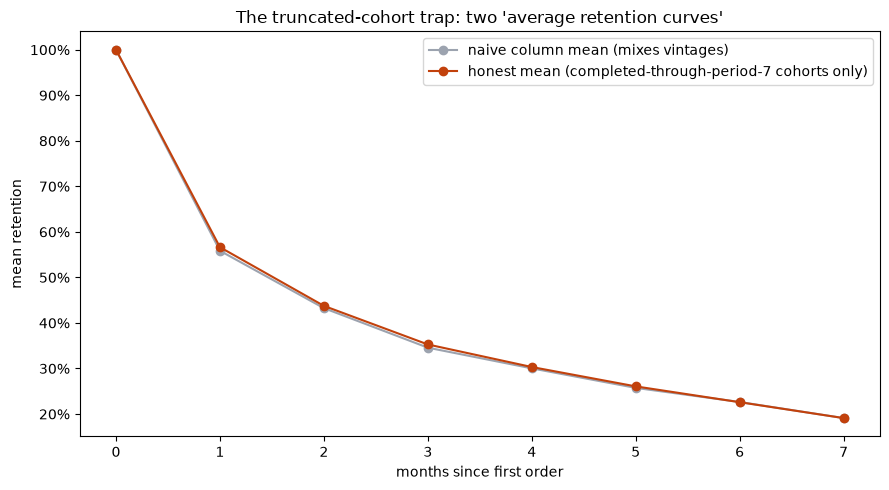

In [3]:
HORIZON = 7  # compare curves over periods 0..7
naive = retention.loc[:, :HORIZON].mean(axis=0)
completed = retention[retention[HORIZON].notna()]
honest = completed.loc[:, :HORIZON].mean(axis=0)
print(f"naive mean uses {len(retention)} cohorts per column (a different subset each column)")
print(f"honest mean uses only the {len(completed)} cohorts that have completed period {HORIZON}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(naive.index, naive.values, marker="o", color="#9CA3AF",
        label="naive column mean (mixes vintages)")
ax.plot(honest.index, honest.values, marker="o", color="#C2410C",
        label=f"honest mean (completed-through-period-{HORIZON} cohorts only)")
ax.set_xlabel("months since first order")
ax.set_ylabel("mean retention")
ax.set_title("The truncated-cohort trap: two 'average retention curves'")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

## 3. The layer-cake

Stack active customers by cohort over calendar months. Investors read this chart directly: if the
old layers hold their thickness, revenue is durable; if every layer melts, the business is a
leaky bucket refilled by acquisition.

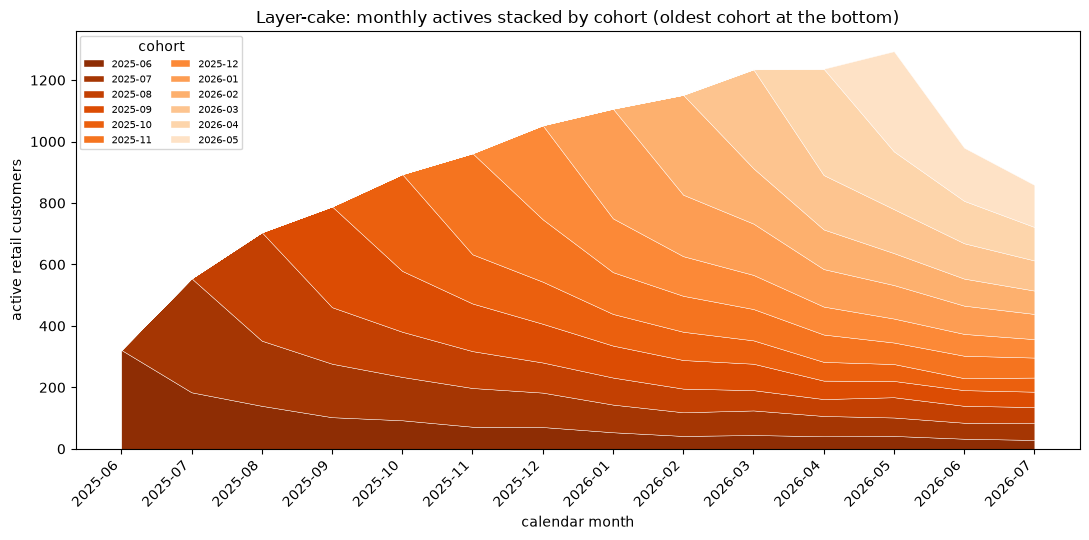

In [4]:
active = retail.pivot_table(index="order_month", columns="cohort",
                            values="customer_id", aggfunc="nunique").fillna(0)
months = active.index.astype(str)
colors = plt.cm.Oranges_r(np.linspace(0.05, 0.85, active.shape[1]))
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(range(len(months)), active.T.values, labels=active.columns.astype(str),
             colors=colors, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45, ha="right")
ax.set_xlabel("calendar month")
ax.set_ylabel("active retail customers")
ax.set_title("Layer-cake: monthly actives stacked by cohort (oldest cohort at the bottom)")
ax.legend(loc="upper left", ncol=2, fontsize=7, title="cohort")
plt.tight_layout()
plt.show()

## 4. Growth accounting and the quick ratio

Every month's active base decomposes exactly: actives = new + retained + resurrected, and the
customers you lost are churned (drawn as negative bars). Quick ratio = (new + resurrected) /
churned; below 1 the base is shrinking no matter what the topline says.

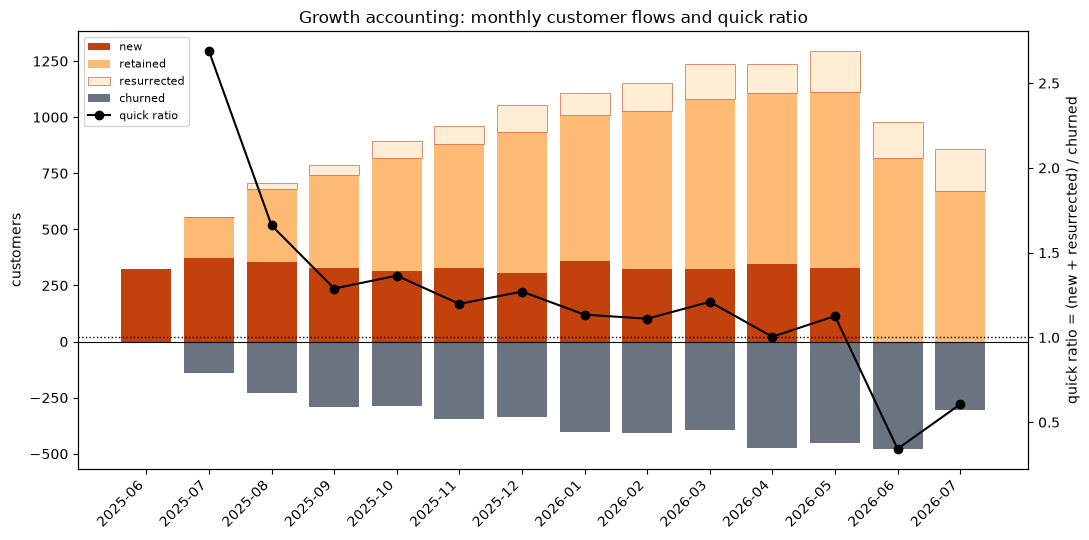

,new,retained,resurrected,churned,quick_ratio
month,,,,,
2026-04,346,762,129,-473,1.000
2026-05,326,787,181,-450,1.130
2026-06,0,816,164,-478,0.340
2026-07,0,673,186,-307,0.610


In [5]:
by_month = retail.groupby("order_month")["customer_id"].agg(set)
first_month = retail.groupby("customer_id")["order_month"].min()
months_idx = by_month.index
rows = []
seen = set()
for i, m in enumerate(months_idx):
    cur = by_month[m]
    prev = by_month[months_idx[i - 1]] if i > 0 else set()
    new = {c for c in cur if first_month[c] == m}
    retained = cur & prev
    resurrected = (cur - prev) - new
    churned = prev - cur
    rows.append({"month": str(m), "new": len(new), "retained": len(retained),
                 "resurrected": len(resurrected), "churned": -len(churned)})
    seen |= cur
ga = pd.DataFrame(rows).set_index("month")
ga["quick_ratio"] = (ga["new"] + ga["resurrected"]) / ga["churned"].abs().replace(0, np.nan)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(ga))
ax.bar(x, ga["new"], label="new", color="#C2410C")
ax.bar(x, ga["retained"], bottom=ga["new"], label="retained", color="#FDBA74")
ax.bar(x, ga["resurrected"], bottom=ga["new"] + ga["retained"],
       label="resurrected", color="#FFEDD5", edgecolor="#C2410C", linewidth=0.4)
ax.bar(x, ga["churned"], label="churned", color="#6B7280")
ax.axhline(0, color="black", linewidth=0.8)
ax2 = ax.twinx()
ax2.plot(x, ga["quick_ratio"], color="black", marker="o", linewidth=1.5, label="quick ratio")
ax2.axhline(1, color="black", linestyle=":", linewidth=1)
ax2.set_ylabel("quick ratio = (new + resurrected) / churned")
ax.set_xticks(x)
ax.set_xticklabels(ga.index, rotation=45, ha="right")
ax.set_ylabel("customers")
ax.set_title("Growth accounting: monthly customer flows and quick ratio")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
ga.tail(4).round(2)

## 5. The L28-style power-user histogram (game data)

A ratio like DAU/MAU hides the distribution. The L28 curve is the histogram of active days per
player over a 28-day window: a smile shape means a genuine hardcore daily segment exists next to
the one-and-done crowd; a pure left-slump means nobody built a habit.

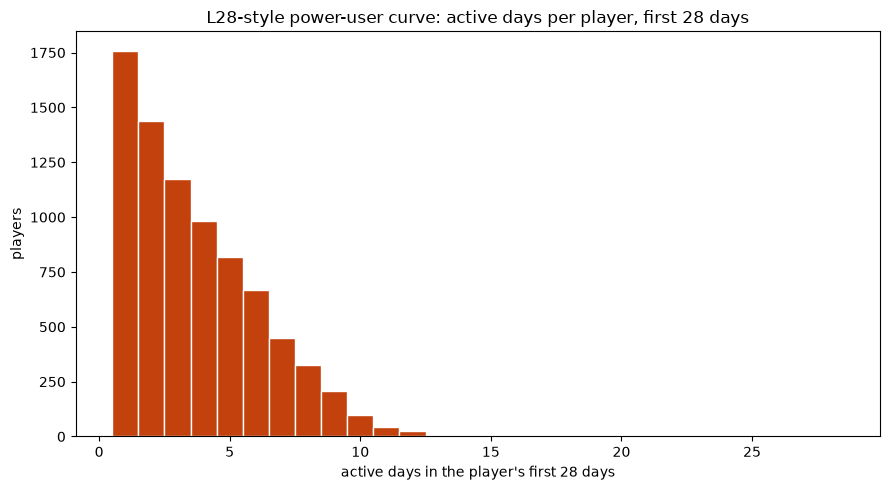

count   8,000.000
mean        3.720
std         2.470
min         1.000
25%         2.000
50%         3.000
75%         5.000
max        14.000
Name: day, dtype: float64


In [6]:
game = pd.read_csv(ROOT / "data" / "game_telemetry.csv",
                   parse_dates=["install_date", "activity_date"])
game["day"] = (game["activity_date"] - game["install_date"]).dt.days
first28 = game[game["day"] <= 27]
active_days = first28.groupby("user_id")["day"].nunique()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(active_days, bins=np.arange(0.5, 29.5, 1), color="#C2410C", edgecolor="white")
ax.set_xlabel("active days in the player's first 28 days")
ax.set_ylabel("players")
ax.set_title("L28-style power-user curve: active days per player, first 28 days")
plt.tight_layout()
plt.show()
print(active_days.describe().round(2))

## MAU composition: who your actives are

Chart 4 showed the monthly FLOWS (new, retained, resurrected, churned as bars). The same
decomposition drawn as a stacked area answers a different question: of everyone active this
month, who are they? This uses the exact month-gaps method from the growth-accounting cell
above, applied to ALL segments (retail plus wholesale) so it matches the course headline
numbers. Months shown: 2025-06 through 2026-05.


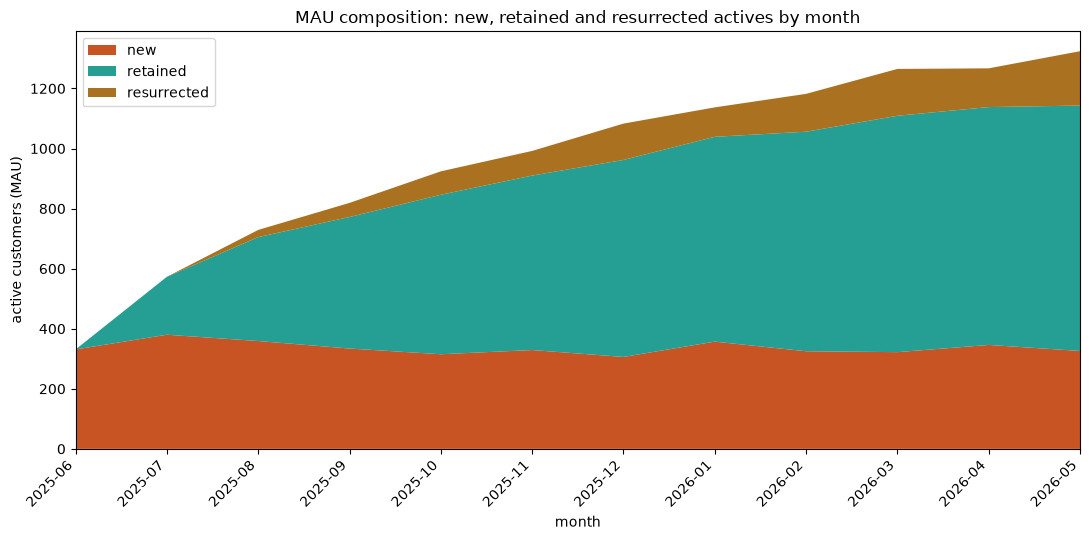

,new,retained,resurrected
month,,,
2025-06,331,0,0
2025-07,380,193,0
2025-08,359,346,24
2025-09,334,438,47
2025-10,315,531,78
2025-11,329,581,82
2025-12,306,656,121
2026-01,357,682,98
2026-02,325,731,126


In [7]:
# Reuse the growth-accounting month-gaps method, on all segments this time
all_o = orders.copy()
all_o["order_month"] = all_o["order_date"].dt.to_period("M")
by_month_all = all_o.groupby("order_month")["customer_id"].agg(set)
first_month_all = all_o.groupby("customer_id")["order_month"].min()
mi = by_month_all.index
comp_rows = []
for i, m in enumerate(mi):
    cur = by_month_all[m]
    prev = by_month_all[mi[i - 1]] if i > 0 else set()
    new = {c for c in cur if first_month_all[c] == m}
    retained = cur & prev
    resurrected = (cur - prev) - new
    comp_rows.append({"month": str(m), "new": len(new), "retained": len(retained),
                      "resurrected": len(resurrected)})
mau = pd.DataFrame(comp_rows).set_index("month").loc["2025-06":"2026-05"]

fig, ax = plt.subplots(figsize=(11, 5.5))
xs = np.arange(len(mau))
ax.stackplot(xs, mau["new"], mau["retained"], mau["resurrected"],
             labels=["new", "retained", "resurrected"],
             colors=["#C2410C", "#0D9488", "#A16207"], alpha=0.9)
ax.set_xticks(xs)
ax.set_xticklabels(mau.index, rotation=45, ha="right")
ax.set_xlabel("month")
ax.set_ylabel("active customers (MAU)")
ax.set_title("MAU composition: new, retained and resurrected actives by month")
ax.legend(loc="upper left")
ax.set_xlim(0, len(mau) - 1)
plt.tight_layout()
plt.show()
mau


**The read**: the new layer is flat at roughly 330 customers a month - acquisition never
accelerated. Everything the eye reads as growth is the retained layer compounding from 0 to
817, with resurrected climbing to 181 behind it. Within a year the composition flips from
acquisition-driven to retention-driven: the same MAU headline would hide this entirely,
which is why MAU should always be decomposed before it is celebrated.
